In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.csgraph import shortest_path
from sklearn.datasets import load_digits, make_s_curve, make_swiss_roll
from sklearn.metrics.pairwise import euclidean_distances as euclidean_distances
from sklearn.manifold import Isomap
from sklearn.neighbors import BallTree
from tqdm.auto import tqdm

plt.style.use("ggplot")
plt.style.use("seaborn-v0_8-colorblind")

ModuleNotFoundError: No module named 'matplotlib'

# Datasets

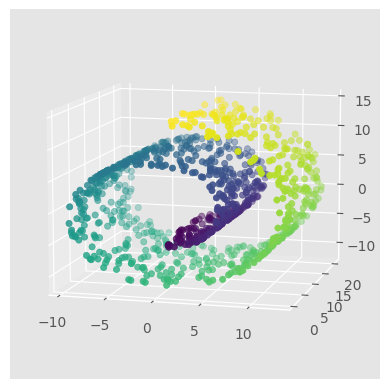

In [7]:
# digits = load_digits()
# data = digits['data']
# labels = digits['target']
# n = data.shape[0]
# data /= 255.0

data, labels = make_swiss_roll(1000)
n = data.shape[0]

# data, labels = make_s_curve(2000)
# n = data.shape[0]

ax = plt.figure().add_subplot(projection="3d")
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=labels)
ax.view_init(elev=10.0, azim=-75, roll=0)

# Sklearn reference

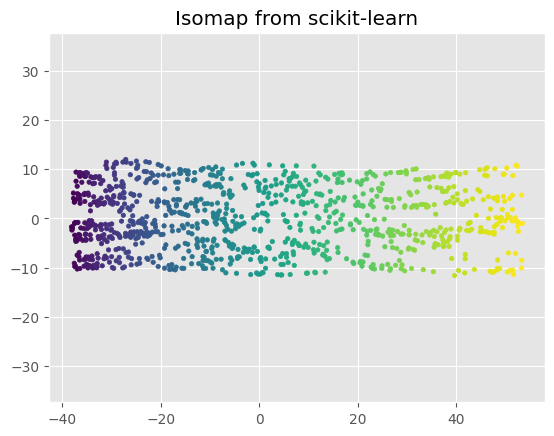

In [8]:
isomap = Isomap(n_neighbors=10)
xy = isomap.fit_transform(data)
plt.scatter(xy[:, 0], xy[:, 1], s=10, c=labels, cmap="viridis")
plt.axis("equal")
plt.title('Isomap from scikit-learn')
plt.show()

## Step 1: Neighbor Graph

In [39]:
def euclidean_pairwise_distance(data):
    """
    Parameters
    ----------
    data : np.ndarray of shape (n, m)
        Data matrix containing n samples, each with m dimensions.
    
    Returns
    -------
    distances : np.ndarray of shape (n, n)
        Pairwise distance matrix, where entry (i, j) gives the distance
        between samples i and j.
    """
    n = data.shape[0]

    # TODO compute euclidean pairwise distance here
    distances = euclidean_distances(data, data)
    
    return distances


def compute_graph(data, k=15, r=None):
    """
    Parameters
    ----------
    data : np.ndarray of shape (n, m)
        Data matrix containing n samples, each with m dimensions.
    
    Returns
    -------
    graph_adj_matrix : np.ndarray of shape (n, n)
        Graph adjacency matrix in which each nonzero entry (i, j) stores the
        distance between connected samples i and j. Entries with value 0 indicate
        that no edge exists between the corresponding samples.
    """
    n = data.shape[0]
    euclidean_pdist = euclidean_pairwise_distance(data)
    
    # Initialize compute adjacency matrix
    graph_adj_matrix = np.zeros([n,n]) 
    
    if r is not None:
        # TODO: compute adjacency matrix here using r-balls
        # np.where(euclidean_pdist < r, euclidean_pdist, 0)
        graph_adj_matrix = np.where(euclidean_pdist < r, euclidean_pdist, 0)
        print(graph_adj_matrix)
        
    else:
        # TODO: compute adjacency matrix here k nearest neightbors
        # argmax of the distances for a given row
        for row_idx in range(len(euclidean_pdist)):
            k_nearest = np.argsort(euclidean_pdist[row_idx])[:k]
            for idx in k_nearest:
                graph_adj_matrix[row_idx][idx] = euclidean_pdist[row_idx][idx]
    return graph_adj_matrix



graph_adj_matrix = compute_graph(data, k = 10)
print(graph_adj_matrix)
np.nonzero(graph_adj_matrix)

[[0.         0.         0.         ... 0.         0.         2.18585086]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


(array([  0,   0,   0, ..., 999, 999, 999], shape=(9000,)),
 array([218, 255, 296, ..., 874, 920, 981], shape=(9000,)))

## Step 2: Shortest Path (given)

In [40]:
shortest_path_distance = shortest_path(graph_adj_matrix)
shortest_path_distance

array([[ 0.        , 39.4047713 , 22.14122532, ..., 30.90736502,
        17.64592795,  2.18585086],
       [40.58124879,  0.        , 60.30229822, ..., 22.35678714,
        36.14228609, 42.11820622],
       [22.54814138, 61.10148679,  0.        , ..., 49.28244642,
        32.28357863, 20.38160312],
       ...,
       [30.74625485, 20.76470334, 46.61328384, ...,  0.        ,
        18.75065815, 32.93210571],
       [17.9435847 , 33.27688094, 28.26460581, ..., 18.32320353,
         0.        , 20.12943555],
       [ 2.34556463, 41.75033593, 20.37421815, ..., 33.25292964,
        19.99149257,  0.        ]], shape=(1000, 1000))

## Step 3: Classical MDS (given)

In [41]:
def classical_mds(pdist, n_components=2):
    n = pdist.shape[0]
    h = -np.ones([n, n]) / n + np.eye(n)
    sim = -1 / 2 * h @ pdist**2 @ h
    try:
        svd = np.linalg.svd(sim)
        xy = svd.U[:, :n_components] * svd.S[:n_components] ** 0.5
    except Exception as e:
        print(e)
        xy = np.random.randn(n,2)
    return xy

xy = classical_mds(shortest_path_distance)
xy.shape

(1000, 2)

## Plot

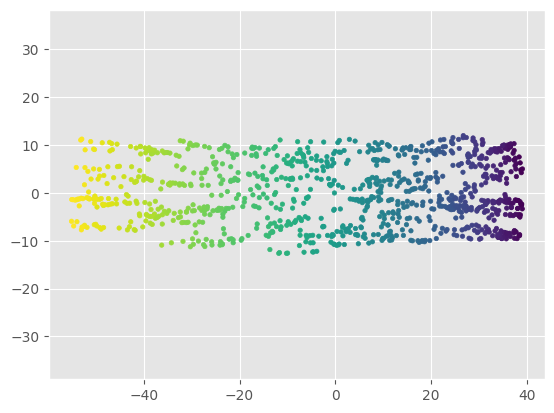

In [42]:
plt.scatter(xy[:, 0], xy[:, 1], s=10, c=labels, cmap="viridis")
plt.axis("equal")
plt.show()